# Prediksi Pinjaman Bank
Eksperimen klasifikasi prediksi kelayakan pinjaman bank menggunakan algoritma Support Vector Machine.

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import accuracy_score

## 2. Load Data

In [2]:
data_loan = pd.read_csv('loan.csv')
data_loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 3. Pengecekan Missing Value dan Preprocessing Data

In [3]:
# Cek ukuran dan missing value data mentah
print("ukuran data :", data_loan.shape)
print("data kosong :")
data_loan.isnull().sum()

ukuran data : (614, 13)
data kosong :
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0


In [4]:
# Membersihkan data kosong
data_loan = data_loan.dropna()
print("data setelah dibersihkan :", data_loan.shape)

data setelah dibersihkan : (480, 13)


In [5]:
# Mengubah nilai kategorikal menjadi representasi numerik
data_loan = data_loan.replace(to_replace='3+', value=4)

data_loan.replace({
    'Married': {'No': 0, 'Yes': 1},
    'Gender': {'Female': 0, 'Male': 1},
    'Self_Employed': {'No': 0, 'Yes': 1},
    'Property_Area': {'Rural': 0, 'Semiurban': 1, 'Urban': 2},
    'Education': {'Not Graduate': 0, 'Graduate': 1},
    'Loan_Status': {'N': 0, 'Y': 1}
}, inplace=True)
data_loan['Dependents'] = data_loan['Dependents'].astype(int)

data_loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


## 4. Exploratory Data Analysis

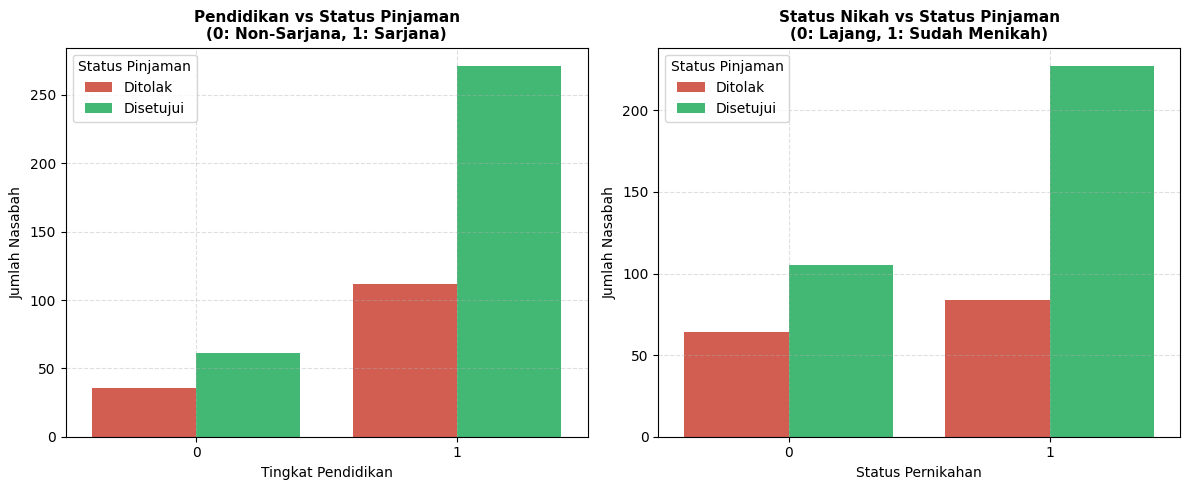

In [6]:
# Grafik batang pengaruh faktor pendidikan dan status perkawinan
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Education', hue='Loan_Status', data=data_loan, palette=['#e74c3c', '#2ecc71'])
plt.title("Pendidikan vs Status Pinjaman\n(0: Non-Sarjana, 1: Sarjana)")

plt.subplot(1, 2, 2)
sns.countplot(x='Married', hue='Loan_Status', data=data_loan, palette=['#e74c3c', '#2ecc71'])
plt.title("Status Nikah vs Status Pinjaman\n(0: Lajang, 1: Sudah Menikah)")

plt.tight_layout()
plt.show()

## 5. Pemisahan Fitur dan Target

In [7]:
X = data_loan.drop(columns=['Loan_ID', 'Loan_Status'], axis=1)
y = data_loan['Loan_Status']

print("Bentuk X :", X.shape)
print("Bentuk y :", y.shape)

Bentuk X : (480, 11)
Bentuk y : (480,)


## 6. Pembagian Data Latih dan Data Uji

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=2)

print("Total Data Nasabah :", X.shape)
print("Data Nasabah Latih :", X_train.shape)
print("Data Nasabah Uji   :", X_test.shape)

Total Data Nasabah : (480, 11)
Data Nasabah Latih : (432, 11)
Data Nasabah Uji   : (48, 11)


## 7. Pelatihan Model Support Vector Machine

In [9]:
# Inisialisasi dan training model SVM
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', svm.SVC(kernel='linear', random_state=2))
])
model.fit(X_train, y_train)

## 8. Evaluasi Performa Model

In [10]:
# Evaluasi akurasi data latih
X_train_prediksi = model.predict(X_train)
akurasi_latih = accuracy_score(X_train_prediksi, y_train)
print("Akurasi Data Latih :", round(akurasi_latih * 100, 2), "%")

# Evaluasi akurasi data uji
X_test_prediksi = model.predict(X_test)
akurasi_uji = accuracy_score(X_test_prediksi, y_test)
print("Akurasi Data Uji   :", round(akurasi_uji * 100, 2), "%")

Akurasi Data Latih : 80.56 %
Akurasi Data Uji   : 83.33 %


## 9. Simulasi Uji Prediksi Data Nasabah Baru

In [11]:
# Simulasi input data nasabah baru
nasabah_baru = pd.DataFrame([[1, 1, 1, 1, 0, 100, 500, 128, 360, 0, 0]], columns=X.columns)
keputusan = model.predict(nasabah_baru)

print("=== HASIL KEPUTUSAN KREDIT BANK ===")
print("Kode Keputusan:", keputusan[0])
if keputusan[0] == 1:
    print("Vonis Bank: SELAMAT! Pengajuan Pinjaman DISETUJUI")
else:
    print("Vonis Bank: MAAF, Pengajuan Pinjaman DITOLAK")

=== HASIL KEPUTUSAN KREDIT BANK ===
Kode Keputusan: 0
Vonis Bank: MAAF, Pengajuan Pinjaman DITOLAK
